# 04 - Feature Engineering

**Project:** E-Commerce User Behavior Analysis & Recommendation System  
**Notebook purpose:** Engineer the behavioral features needed for segmentation, collaborative filtering, A/B testing, and all later modeling notebooks.

---

## Environment Setup

This notebook was run on **Kaggle Notebooks** using the cleaned dataset produced by `02_initial_data_preprocessing.ipynb`.

### To reproduce this notebook

1. Go to the repository on GitHub:  
   [ecommerce-behavior-analysis](https://github.com/halleepham/ecommerce-behavior-analysis)
2. Download `notebooks/04_feature_engineering.ipynb`
3. Open a Kaggle notebook and attach the cleaned dataset output from `02_initial_data_preprocessing.ipynb` as an input **OR** email kylenaluan@gmail.com to request access to the private kaggle dataset 'kylenaluan/ecommerce-data-from-oct-and-nov-cleaned/ecommerce_oct_nov_clean.parquet'
5. Run all cells top to bottom

### Data path

All cells in this notebook use the following path to access the cleaned data:

    /kaggle/input/datasets/kylenaluan/ecommerce-data-from-oct-and-nov-cleaned/ecommerce_oct_nov_clean.parquet

### Python version and key libraries

| Library | Version |
|---|---|
| Python | 3.12.12 |
| pandas | 2.3.3 |
| numpy | 2.0.2 |
| pyplot | 3.10.0 |
| seaborn | 0.13.2 |

---

## Scope

**Feature Engineering:** Derives per-user and per-session behavioral features from the event log. The resulting feature tables are saved as parquet files for use in all downstream notebooks.

In [1]:
%pip install fastparquet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 34.2 MB/s eta 0:00:0000:01
Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import sys
import pandas as pd
import numpy as np
import gc
import fastparquet
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Data Path
CLEAN_FILE = '/kaggle/input/datasets/kylenaluan/ecommerce-data-from-oct-and-nov-cleaned/ecommerce_oct_nov_clean.parquet'
OUTPUT_DIR = '/kaggle/working'

# Verify File Exists
print(f'File exists: {os.path.exists(CLEAN_FILE)}')

print(f'Python : {sys.version}')
print(f'pandas : {pd.__version__}')
print(f'numpy  : {np.__version__}')
print(f'pyplot  : {plt.matplotlib.__version__}')
print(f'seaborn  : {sns.__version__}')

File exists: True
Python : 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
pandas : 2.3.3
numpy  : 2.0.2
pyplot  : 3.10.0
seaborn  : 0.13.2


---

# Feature Engineering

We now derive four feature tables that all downstream notebooks will import:

| Output file | Description | Used in |
|---|---|---|
| `user_features.parquet` | Per-user RFM + behavioral summary | 05, 06, 07 |
| `session_features.parquet` | Per-session summary | 07, 09 |
| `user_category_affinity.parquet` | User × category interaction counts | 06, 08 |
| `product_price_history.parquet` | Daily price per product | 10 |

## User Features (RFM + Behavioral Summary)

For each user we compute:
- **Recency:** days since their last event (relative to the last date in the dataset)
- **Frequency:** total number of events
- **Monetary/Spending:** total spend (sum of purchase prices)
- **Conversion rate:** purchases / views
- **Cart abandonment rate:** (carts with no following purchase) / total cart additions
- **Preferred category and brand**
- **Active days:** number of distinct days the user was seen

This feature table requires the event_time, event_type, category_code, brand, price, user_id columns from the dataset to be computed.

In [2]:
# read only necessary columns from clean data
df = pd.read_parquet(CLEAN_FILE, columns=['event_time', 'event_type', 'category_code', 'brand', 'price', 'user_id'])
df['main_category'] = df['category_code'].apply(
    lambda x: x.split('.', 1)[0]
)
df.drop(columns=['category_code'], inplace=True)

gc.collect()

0

In [41]:
SNAPSHOT_DATE = df['event_time'].max()

# Event counts
event_pivot = (
    df.groupby(['user_id', 'event_type'])
    .size()
    .unstack(fill_value=0)
    .rename(columns={'view': 'n_views', 'cart': 'n_carts', 'purchase': 'n_purchases'})
)
for col in ['n_views', 'n_carts', 'n_purchases']:
    if col not in event_pivot.columns:
        event_pivot[col] = 0

# Recency
last_seen = df.groupby('user_id')['event_time'].max()
recency   = ((SNAPSHOT_DATE - last_seen).dt.total_seconds() / 86400).rename('recency_days')
del last_seen
gc.collect()

# Spending
spending = (
    df[df['event_type'] == 'purchase']
    .groupby('user_id')['price']
    .sum()
    .rename('total_spend')
)

# Active days
active_days = (
    df['event_time'].dt.normalize()
    .rename('date')
    .groupby(df['user_id'])
    .nunique()
    .rename('active_days')
)

# Preferred category and brand
pref_category = (
    df[df['event_type'] == 'view']
    .groupby(['user_id', 'main_category'])
    .size()
    .reset_index(name='count')
    .sort_values('count', ascending=False)
    .drop_duplicates(subset='user_id')
    .set_index('user_id')['main_category']
    .rename('preferred_category')
)
pref_brand = (
    df[(df['event_type'] == 'view') & (df['brand'] != 'unknown')]
    .groupby(['user_id', 'brand'])
    .size()
    .reset_index(name='count')
    .sort_values('count', ascending=False)
    .drop_duplicates(subset='user_id')
    .set_index('user_id')['brand']
    .rename('preferred_brand')
)

# Join everything together
user_features = (
    event_pivot
    .join(recency,       how='left')
    .join(spending,      how='left')
    .join(active_days,   how='left')
    .join(pref_category, how='left')
    .join(pref_brand,    how='left')
)

# Delete intermediate data after join
del event_pivot, recency, spending, active_days, pref_category, pref_brand
gc.collect()

user_features['total_spend'] = user_features['total_spend'].fillna(0)
user_features['conversion_rate'] = (
    user_features['n_purchases'] / user_features['n_views'].replace(0, np.nan)
).fillna(0)
user_features['cart_abandonment_rate'] = (
    1 - (user_features['n_purchases'] / user_features['n_carts'].replace(0, np.nan))
).clip(0, 1).fillna(1)
user_features['avg_spend_per_purchase'] = (
    user_features['total_spend'] / user_features['n_purchases'].replace(0, np.nan)
).fillna(0)

# Save user_features
user_features.to_parquet(f'{OUTPUT_DIR}/user_features.parquet', engine='fastparquet', compression='snappy')
print('user_features saved:', user_features.shape)

user_features saved: (5316649, 11)


In [40]:
# View user_features statistics and preview dataset
print('--- User Feature Summary ---')
print(user_features[['n_views','n_carts','n_purchases','recency_days',
                      'total_spend','conversion_rate','cart_abandonment_rate']].describe().round(3))

user_features.head(5)

--- User Feature Summary ---
           n_views      n_carts  n_purchases  recency_days  total_spend  \
count  5316649.000  5316649.000  5316649.000   5316649.000  5316649.000   
mean        19.624        0.720        0.312        22.006       95.008   
std         52.066        2.849        1.788        17.266      853.281   
min          0.000        0.000        0.000         0.000        0.000   
25%          2.000        0.000        0.000         7.469        0.000   
50%          5.000        0.000        0.000        17.334        0.000   
75%         17.000        0.000        0.000        35.395        0.000   
max      22922.000      565.000      640.000        61.000   343899.094   

       conversion_rate  cart_abandonment_rate  
count      5316649.000            5316649.000  
mean             0.019                  0.931  
std              0.083                  0.227  
min              0.000                  0.000  
25%              0.000                  1.000  
50%    

,n_carts,n_purchases,n_views,recency_days,total_spend,active_days,preferred_category,preferred_brand,conversion_rate,cart_abandonment_rate,avg_spend_per_purchase
user_id,,,,,,,,,,,
10300217,0,0,1,24.713970,0.0,1,unknown,sokolov,0.0,1.0,0.0
29515875,0,0,11,10.333542,0.0,3,furniture,harper,0.0,1.0,0.0
31198833,0,0,20,11.932303,0.0,4,electronics,xiaomi,0.0,1.0,0.0
33869381,0,0,1,38.163785,0.0,1,kids,bumbleride,0.0,1.0,0.0
34916060,0,0,1,6.678079,0.0,1,appliances,tefal,0.0,1.0,0.0


* The distribution of views per user is heavily right-skewed — most users have very few interactions, while a small number of users generate a disproportionate share of total events.
* The median recency is low, meaning most users were last active close to the end of the dataset, which is expected given November's higher overall volume.
* Only a small fraction of users ever made a purchase, reflected in the median n_purchases being 0 or 1 for most users.
* The cart abandonment rate being 1.0 for the majority of users is consistent with the funnel analysis in notebook 03 — most users who browse never add to cart, and those who do often don't follow through to purchase.

### Visualize User Feature Distributions

In [3]:
# Axis Formatting - https://stackoverflow.com/a/67237328
def formatter(x, pos):
    return str(round(x / 1e6, 1))

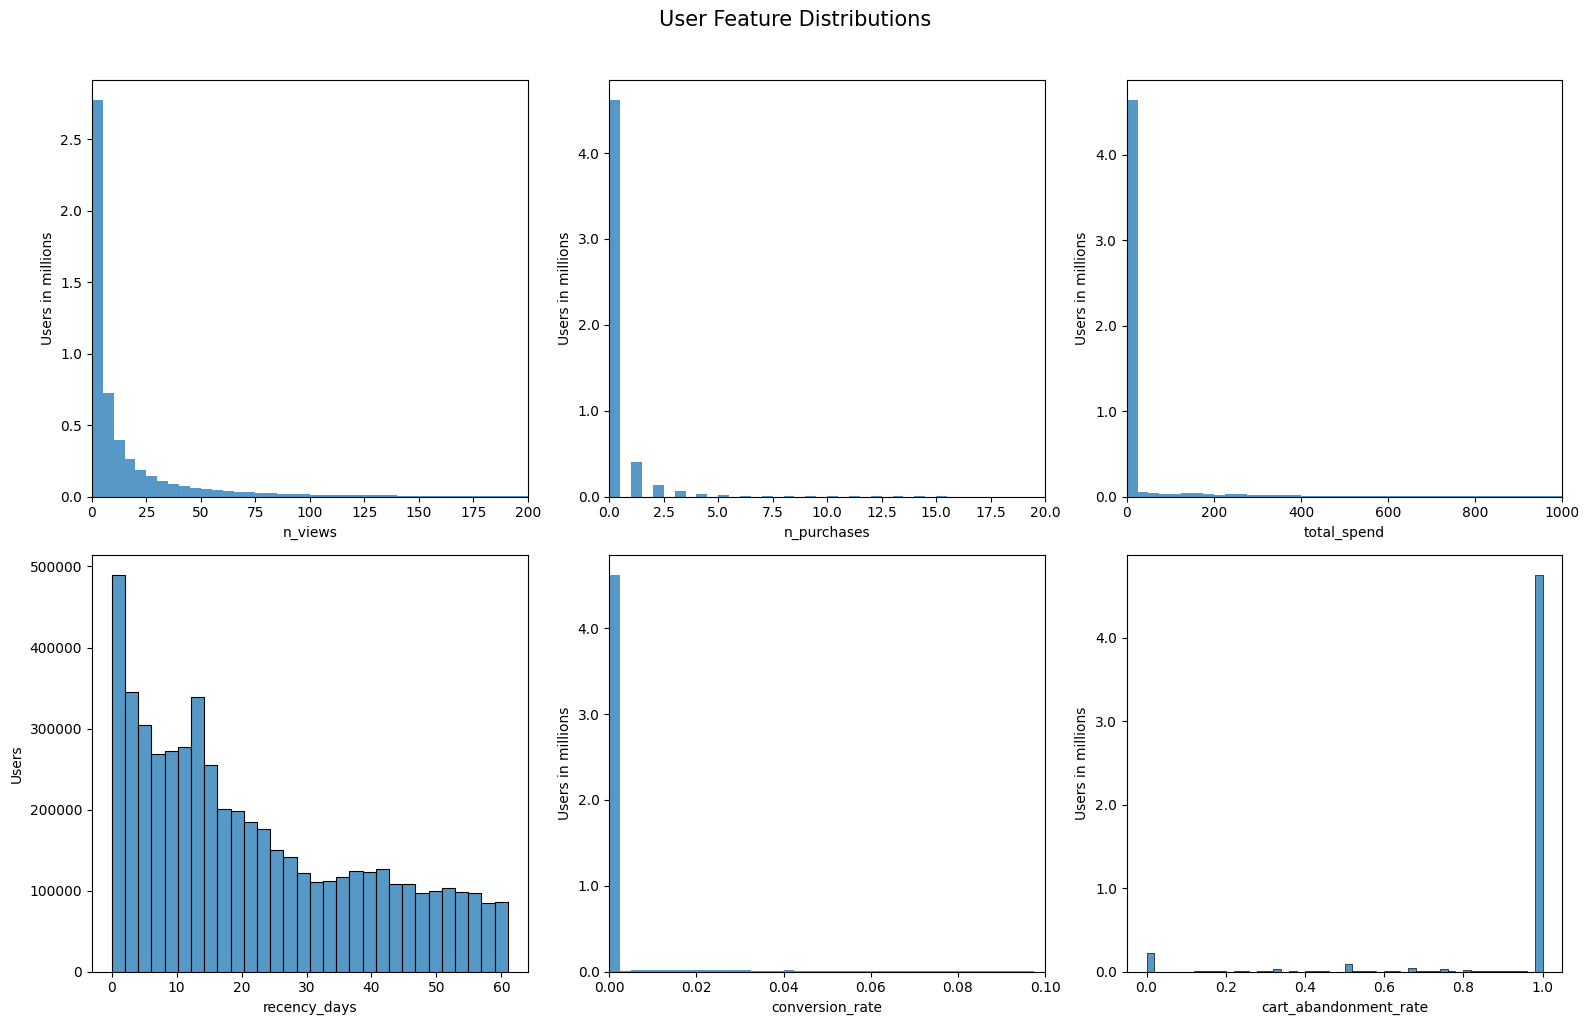

In [38]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

sns.histplot(data=user_features, x='n_views', binwidth=5, ax=axes[0,0])
axes[0,0].set_xlim(0,200)
axes[0,0].yaxis.set_major_formatter(formatter)
axes[0,0].set_ylabel("Users in millions")

sns.histplot(data=user_features, x='n_purchases', binwidth=0.5, ax=axes[0,1])
axes[0,1].set_xlim(0,20)
axes[0,1].yaxis.set_major_formatter(formatter)
axes[0,1].set_ylabel("Users in millions")

sns.histplot(data=user_features, x='total_spend', binwidth=25, ax=axes[0,2])
axes[0,2].set_xlim(0,1000)
axes[0,2].yaxis.set_major_formatter(formatter)
axes[0,2].set_ylabel("Users in millions")

sns.histplot(data=user_features, x='recency_days', binwidth=2, ax=axes[1,0])
axes[1,0].set_ylabel("Users")

sns.histplot(data=user_features, x='conversion_rate', binwidth=0.0025, ax=axes[1,1])
axes[1,1].set_xlim(0,0.1)
axes[1,1].yaxis.set_major_formatter(formatter)
axes[1,1].set_ylabel("Users in millions")

sns.histplot(data=user_features, x='cart_abandonment_rate', binwidth= 0.02, ax=axes[1,2])
axes[1,2].yaxis.set_major_formatter(formatter)
axes[1,2].set_ylabel("Users in millions")

plt.suptitle('User Feature Distributions', fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig('user_feature_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

* The n_views histogram displays the extreme right skew in browsing frequency.
* The n_purchases distribution is concentrated at zero and one, which shows  that purchasing is a rare behavior for most users.
  * The total_spend distribution mirrors this, with most users spending nothing and a long tail of high spenders.
* The conversion rate histogram is almost entirely concentrated below 0.02, confirming that even among users who do purchase, the rate of views converting to purchases is very low.

### Delete User Feature Data to Clear Memory

In [ ]:
del user_features, df
gc.collect()

## Session Features

For each session we compute:
- Duration (seconds between first and last event)
- Number of events, unique products viewed
- Whether the session ended in a purchase
- Whether the session had a cart addition with no purchase (abandoned cart)
- Total revenue in the session

This feature table requires the event_time, event_type, product_id, price, user_id, and user_session columns from the dataset to be computed.

In [4]:
# read only necessary columns from clean data
df = pd.read_parquet(CLEAN_FILE, columns=['event_time', 'event_type', 'product_id', 'price', 'user_id', 'user_session'])

In [8]:
# Session revenue
session_revenue = (
    df[df['event_type'] == 'purchase']
    .groupby('user_session')['price']
    .sum()
    .rename('session_revenue')
)

# Event type counts per session 
session_event_counts = (
    df.groupby(['user_session', 'event_type'])
    .size()
    .unstack(fill_value=0)
    .rename(columns={'view': 'n_views', 'cart': 'n_carts', 'purchase': 'n_purchases'})
)
for col in ['n_views', 'n_carts', 'n_purchases']:
    if col not in session_event_counts.columns:
        session_event_counts[col] = 0

# Remaining aggregations
session_agg = df.groupby('user_session').agg(
    user_id         = ('user_id',    'first'),
    n_events        = ('event_type', 'count'),
    unique_products = ('product_id', 'nunique'),
    session_start   = ('event_time', 'min'),
    session_end     = ('event_time', 'max'),
).reset_index()

# Join everything together
session_agg = (
    session_agg
    .join(session_event_counts, on='user_session', how='left')
    .join(session_revenue,      on='user_session', how='left')
)
session_agg['session_revenue'] = session_agg['session_revenue'].fillna(0)

# Delete intermediate data after join
del session_revenue, session_event_counts
gc.collect()

# Derived columns
session_agg['duration_seconds'] = (
    (session_agg['session_end'] - session_agg['session_start']).dt.total_seconds()
)
session_agg['converted']     = session_agg['n_purchases'] > 0
session_agg['cart_abandoned'] = (session_agg['n_carts'] > 0) & (session_agg['n_purchases'] == 0)
session_agg['hour_of_day']   = session_agg['session_start'].dt.hour
session_agg['day_of_week']   = session_agg['session_start'].dt.day_name()
session_agg['month']         = session_agg['session_start'].dt.month

session_agg.to_parquet(f'{OUTPUT_DIR}/session_features.parquet', engine='fastparquet', compression='snappy')
print('session_features saved:', session_agg.shape)

session_features saved: (23016650, 16)


In [10]:
# View session_features stats and preview dataset
print('--- Session Feature Summary ---')
print(session_agg[['n_events','unique_products','duration_seconds','session_revenue']]
      .describe().round(2))

converted_pct  = session_agg['converted'].mean() * 100
abandoned_pct  = session_agg['cart_abandoned'].mean() * 100
print(f'\nSessions that converted   : {converted_pct:.2f}%')
print(f'Sessions with cart abandon: {abandoned_pct:.2f}%')

session_agg.head(5)

--- Session Feature Summary ---
          n_events  unique_products  duration_seconds  session_revenue
count  23016650.00      23016650.00       23016650.00      23016650.00
mean          4.77             3.03           1100.39            21.95
std           7.44             4.52          28661.99           148.87
min           1.00             1.00              0.00             0.00
25%           1.00             1.00              0.00             0.00
50%           2.00             1.00             61.00             0.00
75%           5.00             3.00            278.00             0.00
max        4128.00          4128.00        5248873.00         82682.32

Sessions that converted   : 6.09%
Sessions with cart abandon: 5.98%


,user_session,user_id,n_events,unique_products,session_start,session_end,n_carts,n_purchases,n_views,session_revenue,duration_seconds,converted,cart_abandoned,hour_of_day,day_of_week,month
0,00000042-3e3f-42f9-810d-f3d264139c50,515483062,2,1,2019-10-18 10:54:45+00:00,2019-10-18 10:55:20+00:00,0,0,2,0.000000,35.0,False,False,10,Friday,10
1,00000056-a206-40dd-b174-a072550fa38c,513782162,8,7,2019-10-31 06:23:12+00:00,2019-10-31 06:31:25+00:00,0,0,8,0.000000,493.0,False,False,6,Thursday,10
2,0000007c-adbf-4ed7-af17-d1fef9763d67,560165420,1,1,2019-11-18 09:16:19+00:00,2019-11-18 09:16:19+00:00,0,0,1,0.000000,0.0,False,False,9,Monday,11
3,00000083-8816-4d58-a9b8-f52f54186edc,546521725,18,14,2019-10-06 11:24:45+00:00,2019-10-06 11:34:30+00:00,1,1,16,289.519989,585.0,True,False,11,Sunday,10
4,0000009d-1f5b-40b9-bd23-db4f3d973ae3,457789173,1,1,2019-11-13 06:02:54+00:00,2019-11-13 06:02:54+00:00,0,0,1,0.000000,0.0,False,False,6,Wednesday,11


* The dataset contains approximately 23 million unique sessions.
* The majority of sessions are short — most contain only a handful of events and the median duration is brief.
* The session outcome breakdown shows that most sessions result in no purchase and no cart addition.

### Visualize Session Feature Distributions

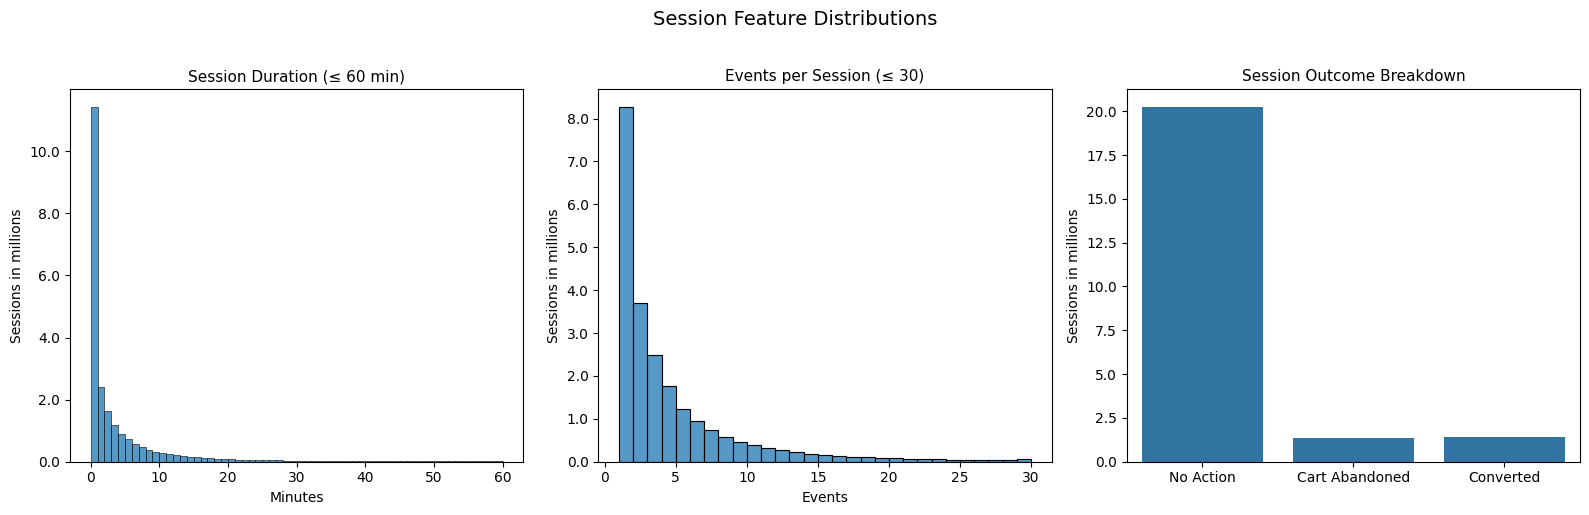

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Duration (cap at 1 hour for readability)
sns.histplot(
    data=session_agg[session_agg['duration_seconds'] <= 3600],
    x=session_agg['duration_seconds'][session_agg['duration_seconds'] <= 3600] / 60,
    binwidth=1,
    ax=axes[0]
)
axes[0].set_title('Session Duration (≤ 60 min)', fontsize=11)
axes[0].set_xlabel('Minutes')
axes[0].yaxis.set_major_formatter(formatter)
axes[0].set_ylabel('Sessions in millions')

# Events per session (cap at 30)
sns.histplot(
    data=session_agg[session_agg['n_events'] <= 30],
    x='n_events',
    binwidth=1,
    ax=axes[1]
)
axes[1].set_title('Events per Session (≤ 30)', fontsize=11)
axes[1].set_xlabel('Events')
axes[1].yaxis.set_major_formatter(formatter)
axes[1].set_ylabel('Sessions in millions')

# Session outcome breakdown — barplot
neither = (~session_agg['converted']) & (~session_agg['cart_abandoned'])
outcome_df = pd.DataFrame({
    'outcome': ['No Action', 'Cart Abandoned', 'Converted'],
    'count':   [neither.sum(), session_agg['cart_abandoned'].sum(), session_agg['converted'].sum()]
})
sns.barplot(data=outcome_df, x='outcome', y='count', ax=axes[2])
axes[2].set_title('Session Outcome Breakdown', fontsize=11)
axes[2].set_xlabel('')
axes[2].yaxis.set_major_formatter(formatter)
axes[2].set_ylabel('Sessions in millions')

plt.suptitle('Session Feature Distributions', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('session_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

* The duration histogram shows a sharp spike of zero-duration sessions — these are single-event sessions where a user viewed one product and left immediately.
* The events-per-session histogram drops off steeply, with most sessions containing fewer than five events.
* The session outcome barplot confirms that the overwhelming majority of sessions are browse-only.

### Delete Session Feature Data to Clear Memory

In [ ]:
del session_agg, df
gc.collect()

## User × Category Affinity

For each (user, category) pair, count the number of views, carts, and purchases. This sparse matrix is the basis for the collaborative filtering notebook (06) and the time-sensitive recommendation notebook (08).

This feature table requires the event_type, category_code, and user_id columns from the dataset to be computed.

In [7]:
# read only necessary columns from clean data
df = pd.read_parquet(CLEAN_FILE, columns=['event_type', 'category_code', 'user_id'])
df['main_category'] = df['category_code'].apply(
    lambda x: x.split('.', 1)[0]
)
df.drop(columns=['category_code'], inplace=True)

gc.collect()

0

In [9]:
# Only keep rows with a known category
df = df[df['main_category'] != 'unknown']
gc.collect()

user_cat_affinity = (
    df.groupby(['user_id', 'main_category', 'event_type'])
    .size()
    .unstack(fill_value=0)
    .rename(columns={'view': 'cat_views', 'cart': 'cat_carts', 'purchase': 'cat_purchases'})
    .reset_index()
)
for col in ['cat_views', 'cat_carts', 'cat_purchases']:
    if col not in user_cat_affinity.columns:
        user_cat_affinity[col] = 0

# Affinity score: weighted interaction score
user_cat_affinity['affinity_score'] = (
    user_cat_affinity['cat_views']     * 1 +
    user_cat_affinity['cat_carts']     * 3 +
    user_cat_affinity['cat_purchases'] * 5
)

user_cat_affinity.to_parquet(f'{OUTPUT_DIR}/user_category_affinity.parquet', engine='fastparquet', compression='snappy')
print('User-category affinity saved:', user_cat_affinity.shape)

User-category affinity saved: (6753416, 6)


In [11]:
# View user_cat_affinity stats and preview dataset
print('--- User Category Affinity Summary ---')
print(user_cat_affinity[['cat_views','cat_carts','cat_purchases','affinity_score']]
      .describe().round(2))

user_cat_affinity.head(5)

--- User Category Affinity Summary ---
event_type  cat_views   cat_carts  cat_purchases  affinity_score
count       6753416.0  6753416.00     6753416.00      6753416.00
mean             10.4        0.43           0.19           12.63
std              26.8        2.03           1.28           32.39
min               0.0        0.00           0.00            1.00
25%               1.0        0.00           0.00            1.00
50%               3.0        0.00           0.00            4.00
75%               9.0        0.00           0.00           11.00
max           13785.0      557.00         630.00        13785.00


event_type,user_id,main_category,cat_carts,cat_purchases,cat_views,affinity_score
0,29515875,electronics,0,0,5,5
1,29515875,furniture,0,0,6,6
2,31198833,appliances,0,0,1,1
3,31198833,electronics,0,0,18,18
4,33869381,kids,0,0,1,1


* It appears that affinity scores, as well as events for each category are right-skewed (mean > median)
* The highest affinity score comes from a user x category pair where the user had only viewed the category many times.

### Visualize Affinity Scores by Category

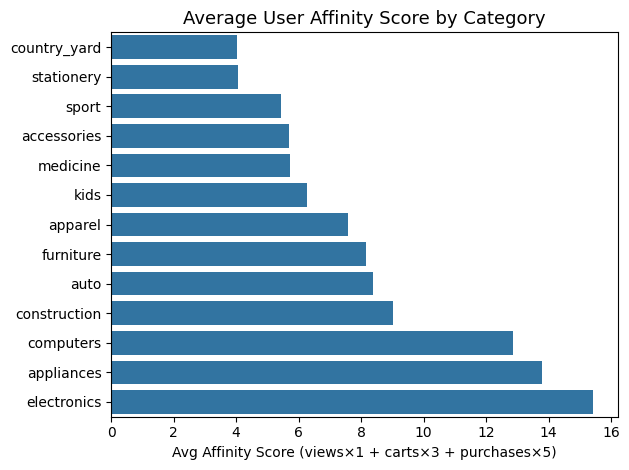

In [13]:
cat_affinity_summary = (
    user_cat_affinity.groupby('main_category')['affinity_score']
    .mean()
    .sort_values(ascending=True)
    .reset_index()
)

sns.barplot(
    data=cat_affinity_summary,
    x='affinity_score',
    y='main_category',
)
plt.title('Average User Affinity Score by Category', fontsize=13)
plt.xlabel('Avg Affinity Score (views×1 + carts×3 + purchases×5)')
plt.ylabel('')
plt.tight_layout()
plt.savefig('category_affinity.png', dpi=300, bbox_inches='tight')
plt.show()

The affinity table captures interactions across 13 known top-level categories after filtering out unknown values.
* Electronics has the highest average affinity score by a considerable margin, which is consistent with it being the dominant category in both the views and purchases charts from notebook 03.
  * It is followed by appliances, then computers.

### Delete User Category Affinity Data to Clear Memory

In [ ]:
del user_cat_affinity, cat_affinity_summary, df
gc.collect()

## Product Price History

For each product, record the median observed price per day. Used in notebook 10 (purchase timing predictor) to detect price drops and compute price percentiles.

This feature table requires the event_time, product_id, and price columns from the dataset to be computed.

In [17]:
# read only necessary columns from clean data
df = pd.read_parquet(CLEAN_FILE, columns=['event_time', 'product_id', 'price'])

In [18]:
product_price_history = (
    df['price']
    .where(df['price'].notna())
    .groupby([df['product_id'], df['event_time'].dt.normalize()])
    .median()
    .rename('median_price')
    .reset_index()
)
product_price_history.columns = ['product_id', 'date', 'median_price']

# Add 30-day rolling stats per product for notebook 10
product_price_history = product_price_history.sort_values(['product_id', 'date'])
product_price_history['price_30d_avg'] = (
    product_price_history.groupby('product_id')['median_price']
    .transform(lambda x: x.rolling(30, min_periods=1).mean())
)
product_price_history['price_30d_min'] = (
    product_price_history.groupby('product_id')['median_price']
    .transform(lambda x: x.rolling(30, min_periods=1).min())
)
product_price_history['price_30d_max'] = (
    product_price_history.groupby('product_id')['median_price']
    .transform(lambda x: x.rolling(30, min_periods=1).max())
)

# Price percentile: price relative to 30-day range
price_range = product_price_history['price_30d_max'] - product_price_history['price_30d_min']
product_price_history['price_30d_pct'] = (
    (product_price_history['median_price'] - product_price_history['price_30d_min'])
    / price_range.replace(0, np.nan)
).fillna(0.5)

product_price_history.to_parquet(f'{OUTPUT_DIR}/product_price_history.parquet', engine='fastparquet', compression='snappy')
print('Product price history saved:', product_price_history.shape)

Product price history saved: (4998112, 7)


In [19]:
# View product_price_history stats and preview dataset
product_price_history.head(5)

,product_id,date,median_price,price_30d_avg,price_30d_min,price_30d_max,price_30d_pct
0,1000365,2019-11-05 00:00:00+00:00,1029.089966,1029.089966,1029.089966,1029.089966,0.5
1,1000978,2019-10-21 00:00:00+00:00,333.489990,333.489990,333.489990,333.489990,0.5
2,1000978,2019-10-22 00:00:00+00:00,300.910004,317.199997,300.910004,333.489990,0.0
3,1000978,2019-10-23 00:00:00+00:00,333.489990,322.629995,300.910004,333.489990,1.0
4,1000978,2019-10-24 00:00:00+00:00,333.489990,325.344994,300.910004,333.489990,1.0


The price history table contains approximately 5 million (product, date) pairs over 61 days.
* The preview shows product 1000978 as a clear example of the rolling statistics working correctly
  * On October 22 the price drops from $333.49 to $300.91, giving a price_30d_pct of 0.0 (the 30-day low), and then recovers on October 23, jumping back to a price_30d_pct of 1.0 (the 30-day high).
* Products that first appear in the dataset with no prior history, like product 1000365, correctly receive a price_30d_pct of 0.5 since there is no range to compare against yet.
* This table is the primary input for the purchase timing predictor in notebook 10.

In [20]:
del product_price_history, price_range
gc.collect()

30

All four output parquet files uploaded as private Kaggle datasets and attached to subsequent notebooks. Contact kylenaluan@gmail.com for access.

---

## Summary

### Feature Tables Produced
| File | Rows | Key columns |
|---|---|---|
| `user_features.parquet` | ~5.6M users | RFM scores, rates, preferred category/brand |
| `session_features.parquet` | ~23M sessions | duration, conversion flag, abandonment flag |
| `user_category_affinity.parquet` | ~user×category pairs | affinity score per category |
| `product_price_history.parquet` | ~product×day pairs | rolling 30-day price stats |